In [1]:
from pathlib import Path
import numpy as np
import jax.numpy as jnp
from jax import random
from sklearn.metrics import r2_score

from tensorflow_probability.substrates.jax import distributions as tfd
import optax

from sbijax import CMPE
from sbijax.nn import make_cm

import matplotlib.pyplot as plt

### Import and prepare data

In [2]:
data_dir = Path("./dt-data-time1/")
# n_batches = 10
n_batches = 1 # smaller test case

theta_indices = (3, 5, 7, 9, 11, 13) # only positions

In [3]:
theta_list = []
for i in range(n_batches):
    file_path = data_dir / f"theta_batch_{i:02d}.npy"
    theta = np.load(file_path)
    theta_list.append(theta)

theta_orig = jnp.concatenate(theta_list, axis=0)
theta = theta_orig[:, theta_indices]

ERROR:2026-04-28 17:57:49,751:jax._src.xla_bridge:477: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/lugur3/miniconda3/envs/sbijax_env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 201, in _version_check
    version = get_version()
              ^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/lugur3/miniconda3/envs/sbijax_env/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 475, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/lugur3/miniconda3/envs/sbijax_env/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/h

In [4]:
x_list = []
for i in range(n_batches):
    file_path = data_dir / f"x_batch_{i:02d}.npy"
    x = np.load(file_path)       # shape: (N_batch, n_observables)
    x_list.append(x)

x = jnp.concatenate(x_list, axis=0)

# mass_info = theta_orig[:, :3]
# x = jnp.concatenate([mass_info, x], axis=1)

In [5]:
# Split test set
test_ratio = 0.1
theta_test = theta[int((1.0-test_ratio)*theta.shape[0]):]
theta = theta[:int((1.0-test_ratio)*theta.shape[0])]
x_test = x[int((1.0-test_ratio)*x.shape[0]):]
x = x[:int((1.0-test_ratio)*x.shape[0])]

In [6]:
# Scale x
x_mean = x.mean(axis=0)
x_std = x.std(axis=0)
x_std = jnp.where(x_std == 0, 1.0, x_std)

x = (x - x_mean) / x_std
x_test = (x_test - x_mean) / x_std

In [7]:
print("Theta shape: ", theta.shape)
print("x shape:     ", x.shape)

print("Theta test shape: ", theta_test.shape)
print("x test shape:     ", x_test.shape)

Theta shape:  (8999, 6)
x shape:      (8999, 12)
Theta test shape:  (1000, 6)
x test shape:      (1000, 12)


### Set prior distribution

In [8]:
n_dim_theta = theta.shape[1]
n_dim_x = x.shape[1]

# Set prior
def prior_fn():
    low  = jnp.array([0.1, 0.1, 0.1, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0, 0.1, 0])[np.array(theta_indices)]
    high =  jnp.array([10.0, 10.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0, 5.0, 10.0])[np.array(theta_indices)]
    prior = tfd.JointDistributionNamed(dict(
        theta=tfd.Independent(
            tfd.Uniform(low=low, high=high),
            reinterpreted_batch_ndims=1
        )
    ), batch_ndims=0)
    return prior

### Train NPE Model

In [9]:
neural_network = make_cm(
    n_dimension=n_dim_theta,
    n_layers=2,
    hidden_size=128,
)

fns = (prior_fn, None)
estim = CMPE(fns, neural_network)

In [10]:
# Train model
data = {"theta": theta, "y": x}

params, info = estim.fit(
    random.PRNGKey(0),
    data=data,
    optimizer=optax.adam(1e-3),
    n_epochs=1000,
    n_early_stopping_patience=100,
    n_early_stopping_delta=0.0,
)

print("Training finished.")

 14%|█▍        | 139/1000 [03:19<20:38,  1.44s/it]

Training finished.


### Test the trained model with a seen case

In [11]:
x_obs = x[0]
posterior_samples, _ = estim.sample_posterior(
    random.PRNGKey(1),
    params,
    observable=x_obs,
    n_samples=1000,
)

In [12]:
print("True positions:")
print(theta[0])
print("\n")
print("NPE Prediction:")
print(jnp.mean(posterior_samples.posterior["theta"].values[0], axis=0))

True positions:
[2.7710838  1.1384773  4.658235   1.4685215  3.0610204  0.38042083]


NPE Prediction:
[2.2948349 1.2142311 4.3487782 0.7971968 2.5773993 0.9947062]


### Test the trained model with an unseen case

In [13]:
x_obs = x_test[0]
posterior_samples, _ = estim.sample_posterior(
    random.PRNGKey(1),
    params,
    observable=x_obs,
    n_samples=1000,
)

In [14]:
print("True positions:")
print(theta_test[0])
print("\n")
print("NPE Prediction:")
print(jnp.mean(posterior_samples.posterior["theta"].values[0], axis=0))

True positions:
[1.7698475 1.0852685 3.0319588 2.348696  1.2756475 2.6660037]


NPE Prediction:
[1.8939147 0.7021488 2.4538722 2.8827593 1.4770826 1.913155 ]


### Calculate R2 score across the datasets

In [15]:
posterior_means = []
posterior_stds = []

rng = np.random.default_rng(42)
eval_indices = rng.choice(len(x), size=100, replace=False)
for i in eval_indices:
    samples, _ = estim.sample_posterior(
        random.PRNGKey(i),
        params,
        observable=x[i],
        n_samples=1000,
    )
    theta_samples = samples.posterior["theta"].values.squeeze(0)
    posterior_means.append(theta_samples.mean(axis=0))
    posterior_stds.append(theta_samples.std(axis=0))

posterior_means = np.array(posterior_means)  # (n_test, 15)
posterior_stds = np.array(posterior_stds)  # (n_test, 15)

# R2 per dimension and overall
r2_per_dim = r2_score(theta[eval_indices], posterior_means, multioutput="raw_values")
r2_overall = r2_score(theta[eval_indices], posterior_means)

print("TRAINING SET:")
print("R² per theta dimension:")
for i, r in enumerate(r2_per_dim):
    print(f"  θ{i}: {r:.4f}")
print(f"\nOverall R²: {r2_overall:.4f}")

TRAINING SET:
R² per theta dimension:
  θ0: 0.7556
  θ1: 0.7037
  θ2: 0.7067
  θ3: 0.5844
  θ4: 0.6780
  θ5: 0.7535

Overall R²: 0.6970


In [18]:
posterior_means = []
posterior_stds = []

rng = np.random.default_rng(42)
eval_indices = rng.choice(len(x_test), size=100, replace=False)
for i in eval_indices:
    samples, _ = estim.sample_posterior(
        random.PRNGKey(i),
        params,
        observable=x_test[i],
        n_samples=100,
    )
    theta_samples = samples.posterior["theta"].values.squeeze(0)
    posterior_means.append(theta_samples.mean(axis=0))
    posterior_stds.append(theta_samples.std(axis=0))

posterior_means = np.array(posterior_means)  # (n_test, 15)
posterior_stds = np.array(posterior_stds)  # (n_test, 15)

# R2 per dimension and overall
r2_per_dim = r2_score(theta_test[eval_indices], posterior_means, multioutput="raw_values")
r2_overall = r2_score(theta_test[eval_indices], posterior_means)

print("TEST SET:")
print("R² per theta dimension:")
for i, r in enumerate(r2_per_dim):
    print(f"  θ{i}: {r:.4f}")
print(f"\nOverall R²: {r2_overall:.4f}")

TEST SET:
R² per theta dimension:
  θ0: 0.6282
  θ1: 0.8271
  θ2: 0.5983
  θ3: 0.4419
  θ4: 0.6854
  θ5: 0.7328

Overall R²: 0.6523


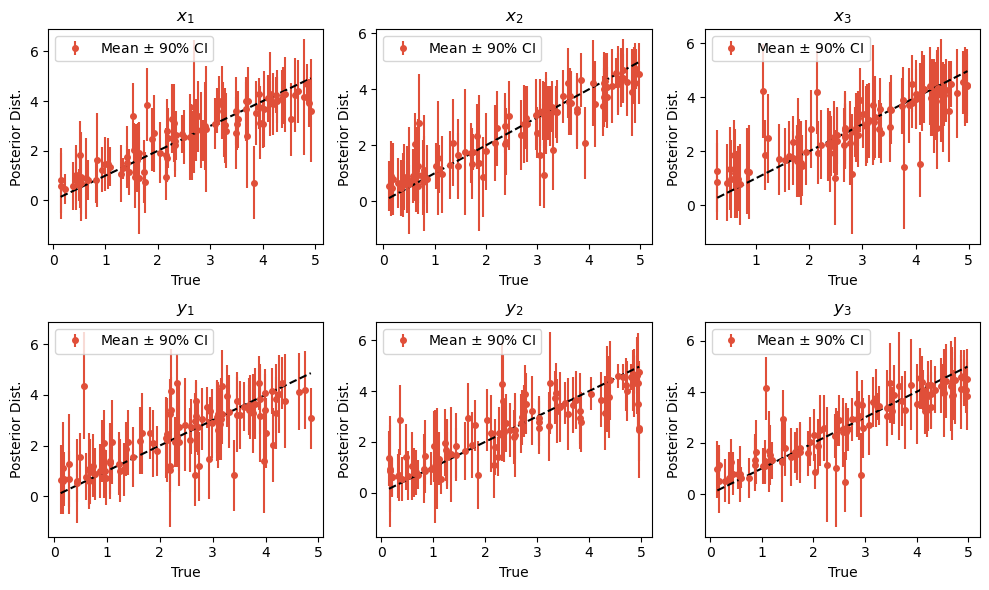

In [23]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10})
theta_names = ["$x_1$", "$x_2$", "$x_3$", "$y_1$", "$y_2$", "$y_3$"]

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
# fig.suptitle("SBIJAX - NPE - 3body - t = 1.0 s", fontsize=22)
axes = axes.flatten()

for i in range(2):
    for n in range(3):  # top and bottom row
        j = 3*i+n
        ax = axes[j]

        ax.errorbar(
            theta_test[eval_indices][:, j],
            posterior_means[:, j],
            yerr=1.64 * posterior_stds[:, j],
            fmt='o', color="#E04F39",
            markersize=4, label=r"Mean $\pm$ 90% CI"
        )

        mn = min(theta_test[eval_indices][:,j].min(), posterior_means[:, j].min())
        mx = max(theta_test[eval_indices][:,j].max(), posterior_means[:, j].max())

        ax.plot([mn, mx], [mn, mx], '--', color="black")

        ax.set_title(theta_names[j])
        ax.set_xlabel("True")
        ax.set_ylabel("Posterior Dist.")
        ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig("./sbijax_CMNPE_result.eps", bbox_inches="tight", dpi=300)